# Analisis de A/B Testing - Hillstrom MineThatData

Dataset de campana de email marketing con 64,000 clientes. Este notebook realiza un analisis de A/B testing comparando el grupo de control (No E-Mail) contra los grupos que recibieron email (Mens E-Mail y Womens E-Mail).


## 1. Configuracion y Carga de Datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, confint_proportions_2indep, proportion_confint
import warnings
warnings.filterwarnings('ignore')

# Configuracion de estilo
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Colores para control y tratamiento
CTRL_COLOR = '#2E86AB'
TRT_COLOR = '#A23B72'

print("Librerias importadas correctamente.")
print(f"pandas {pd.__version__}, numpy {np.__version__}, scipy, statsmodels, matplotlib, seaborn")


Librerias importadas correctamente.
pandas 3.0.3, numpy 2.4.6, scipy, statsmodels, matplotlib, seaborn


In [2]:
df = pd.read_csv(r'/home/tescobarr/Projects/uplift-modeling/data/hillstrom.csv')
print("Shape del dataset:", df.shape)
print()
df.head(10)


Shape del dataset: (64000, 12)



,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
6,9,3) $200 - $350,280.20,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
7,9,1) $0 - $100,46.42,0,1,Urban,0,Phone,Womens E-Mail,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0
9,10,1) $0 - $100,32.84,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


In [3]:
# Crear columna treatment: 0 = No E-Mail (control), 1 = Mens E-Mail o Womens E-Mail
df['treatment'] = np.where(df['segment'] == 'No E-Mail', 0, 1)

# Verificar distribucion
print("=== DISTRIBUCION DE TREATMENT ===")
print(df['treatment'].value_counts())
print()
print("=== CRUCE: SEGMENT vs TREATMENT ===")
print(pd.crosstab(df['segment'], df['treatment'], margins=True))


=== DISTRIBUCION DE TREATMENT ===
treatment
1    42694
0    21306
Name: count, dtype: int64

=== CRUCE: SEGMENT vs TREATMENT ===
treatment          0      1    All
segment                           
Mens E-Mail        0  21307  21307
No E-Mail      21306      0  21306
Womens E-Mail      0  21387  21387
All            21306  42694  64000


In [4]:
# Estadisticas basicas
print("=== RECAP ESTADISTICO ===")
print(f"Total de registros: {len(df):,}")
print(f"Control (No E-Mail): {df['treatment'].eq(0).sum():,} ({df['treatment'].eq(0).mean()*100:.1f}%)")
print(f"Tratamiento (Mens + Womens): {df['treatment'].sum():,} ({df['treatment'].mean()*100:.1f}%)")
print()
print(f"Tasa de conversion global: {df['conversion'].mean()*100:.2f}%")
print(f"Tasa de visita global:     {df['visit'].mean()*100:.2f}%")
print()

# Resumen por segmento
summary = df.groupby('segment')[['conversion', 'visit']].agg(['mean', 'count']).round(4)
summary.columns = ['conversion_tasa', 'conversion_n', 'visit_tasa', 'visit_n']
summary['conversion_tasa'] = summary['conversion_tasa'].mul(100).round(2)
summary['visit_tasa'] = summary['visit_tasa'].mul(100).round(2)
print("=== RESUMEN POR SEGMENTO ===")
print(summary)


=== RECAP ESTADISTICO ===
Total de registros: 64,000
Control (No E-Mail): 21,306 (33.3%)
Tratamiento (Mens + Womens): 42,694 (66.7%)

Tasa de conversion global: 0.90%
Tasa de visita global:     14.68%

=== RESUMEN POR SEGMENTO ===
               conversion_tasa  conversion_n  visit_tasa  visit_n
segment                                                          
Mens E-Mail               1.25         21307       18.28    21307
No E-Mail                 0.57         21306       10.62    21306
Womens E-Mail             0.88         21387       15.14    21387


## 2. Analisis de Lift Global (Overall Lift Analysis)


In [5]:
def compute_lift(df, outcome, treatment_col='treatment'):
    # Calcula tasas de control y tratamiento, y el lift absoluto y relativo.
    #
    # Parametros
    # ----------
    # df : DataFrame
    # outcome : str - nombre de la columna binaria de resultado
    # treatment_col : str - columna binaria (0=control, 1=tratamiento)
    #
    # Retorna
    # -------
    # dict con tasas y lifts
    control_rate = df.loc[df[treatment_col] == 0, outcome].mean()
    treatment_rate = df.loc[df[treatment_col] == 1, outcome].mean()
    absolute_lift = treatment_rate - control_rate
    relative_lift = (absolute_lift / control_rate) * 100 if control_rate > 0 else np.nan

    return {
        'outcome': outcome,
        'control_rate': control_rate,
        'treatment_rate': treatment_rate,
        'absolute_lift': absolute_lift,
        'relative_lift': relative_lift
    }

for outcome in ['conversion', 'visit']:
    res = compute_lift(df, outcome)
    print(f"=== RESULTADO: {outcome.upper()} ===")
    print(f"  Control ({outcome}):      {res['control_rate']*100:.4f}%")
    print(f"  Tratamiento ({outcome}):  {res['treatment_rate']*100:.4f}%")
    print(f"  Lift absoluto:            {res['absolute_lift']*100:.4f} p.p.")
    print(f"  Lift relativo:            {res['relative_lift']:.2f}%")
    print()


=== RESULTADO: CONVERSION ===
  Control (conversion):      0.5726%
  Tratamiento (conversion):  1.0681%
  Lift absoluto:            0.4955 p.p.
  Lift relativo:            86.53%

=== RESULTADO: VISIT ===
  Control (visit):      10.6167%
  Tratamiento (visit):  16.7049%
  Lift absoluto:            6.0882 p.p.
  Lift relativo:            57.35%



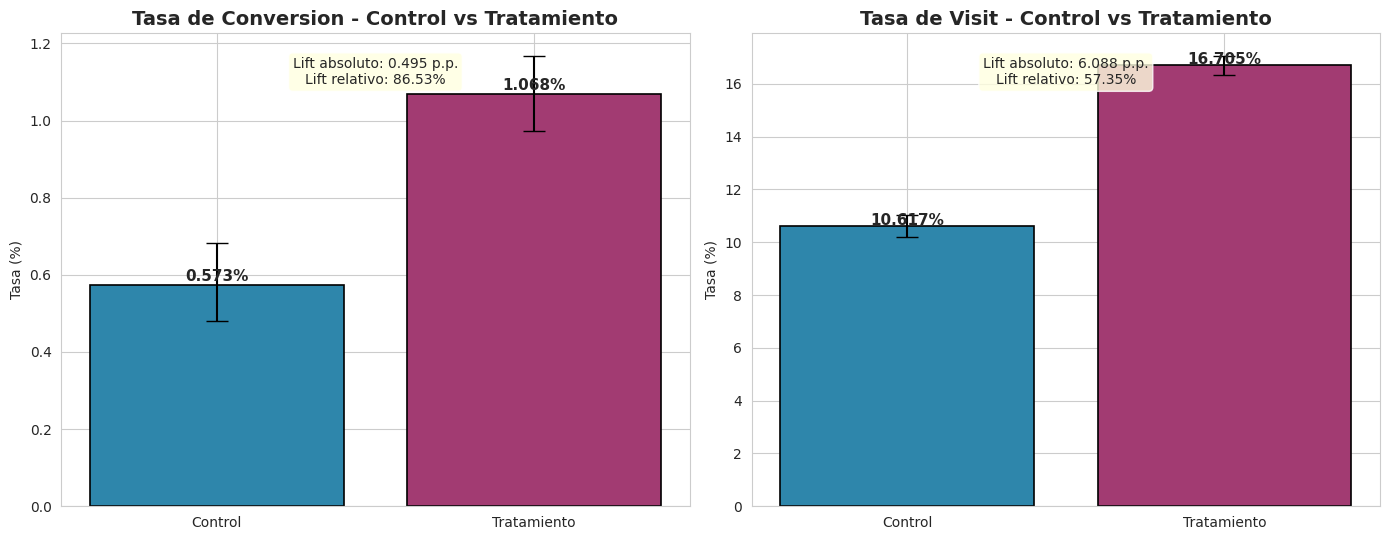

In [6]:
# Bar chart con intervalos de confianza para ambos outcomes
def plot_lift_with_ci(df, outcome, ax):
    # Grafica tasas de control y tratamiento con IC del 95%.
    control = df[df['treatment'] == 0][outcome]
    treatment = df[df['treatment'] == 1][outcome]

    n_c = len(control)
    n_t = len(treatment)
    p_c = control.mean()
    p_t = treatment.mean()

    # IC del 95% para proporciones (Wilson)
    ci_c = proportion_confint(int(p_c * n_c), n_c, alpha=0.05, method='wilson')
    ci_t = proportion_confint(int(p_t * n_t), n_t, alpha=0.05, method='wilson')

    rates = [p_c * 100, p_t * 100]
    errs = [
        [(rates[0] - ci_c[0]*100), (ci_c[1]*100 - rates[0])],
        [(rates[1] - ci_t[0]*100), (ci_t[1]*100 - rates[1])]
    ]
    errs = np.array(errs).T

    bars = ax.bar(['Control', 'Tratamiento'], rates,
                  yerr=errs, capsize=8,
                  color=[CTRL_COLOR, TRT_COLOR],
                  edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Tasa (%)')
    ax.set_title(f'Tasa de {outcome.capitalize()} - Control vs Tratamiento', fontsize=14, fontweight='bold')

    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(errs[1])*0.1,
                f'{rate:.3f}%', ha='center', fontsize=11, fontweight='bold')

    # Agregar linea de lift
    abs_lift = p_t - p_c
    rel_lift = (abs_lift / p_c) * 100 if p_c > 0 else 0
    ax.annotate(f'Lift absoluto: {abs_lift*100:.3f} p.p.\nLift relativo: {rel_lift:.2f}%',
                xy=(0.5, 0.95), xycoords='axes fraction', ha='center', va='top',
                fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    return bars

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_lift_with_ci(df, 'conversion', axes[0])
plot_lift_with_ci(df, 'visit', axes[1])
plt.tight_layout()
plt.show()


## 3. Significancia Estadistica


In [7]:
def chi_square_test(df, outcome, treatment_col='treatment'):
    # Realiza test Chi-cuadrado de independencia entre treatment y outcome.
    tabla = pd.crosstab(df[treatment_col], df[outcome])
    chi2, p_val, dof, expected = chi2_contingency(tabla)
    return chi2, p_val, dof, expected, tabla

def z_test_proportions(df, outcome, treatment_col='treatment'):
    # Realiza Z-test de dos proporciones (test de hipotesis bilateral).
    control = df[df[treatment_col] == 0][outcome]
    treatment = df[df[treatment_col] == 1][outcome]

    n_c = len(control)
    n_t = len(treatment)
    p_c = control.mean()
    p_t = treatment.mean()

    # Proporcion combinada
    p_pool = (p_c * n_c + p_t * n_t) / (n_c + n_t)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))

    z_stat = (p_t - p_c) / se if se > 0 else 0
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))  # bilateral

    return z_stat, p_value, p_c, p_t, n_c, n_t

def cohens_h(p1, p2):
    # Calcula el tamano del efecto Cohen's h.
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

def interpretacion_effect_size(h):
    # Interpreta el tamano del efecto segun Cohen.
    h_abs = abs(h)
    if h_abs < 0.2:
        return "Efecto pequeno"
    elif h_abs < 0.5:
        return "Efecto mediano"
    else:
        return "Efecto grande"

print("=" * 60)
print("CHI-CUADRADO: CONVERSION ~ TREATMENT")
print("=" * 60)
chi2_c, p_c, dof_c, exp_c, tab_c = chi_square_test(df, 'conversion')
print(f"Estadistico X2 = {chi2_c:.4f}")
print(f"Grados de libertad = {dof_c}")
print(f"Valor p = {p_c:.6f}")
print()
print("Tabla de contingencia (observada):")
print(tab_c)
print()
print("Tabla de contingencia (esperada):")
print(pd.DataFrame(exp_c, index=tab_c.index, columns=tab_c.columns).round(2))
print()
alpha = 0.05
if p_c < alpha:
    print(f"-> p < {alpha}: RECHAZAMOS H0. La conversion NO es independiente del tratamiento.")
else:
    print(f"-> p >= {alpha}: No podemos rechazar H0.")
print()

print("=" * 60)
print("CHI-CUADRADO: VISITA ~ TREATMENT")
print("=" * 60)
chi2_v, p_v, dof_v, exp_v, tab_v = chi_square_test(df, 'visit')
print(f"Estadistico X2 = {chi2_v:.4f}")
print(f"Grados de libertad = {dof_v}")
print(f"Valor p = {p_v:.6f}")
print()
print("Tabla de contingencia (observada):")
print(tab_v)
print()
if p_v < alpha:
    print(f"-> p < {alpha}: RECHAZAMOS H0. La visita NO es independiente del tratamiento.")
else:
    print(f"-> p >= {alpha}: No podemos rechazar H0.")


CHI-CUADRADO: CONVERSION ~ TREATMENT
Estadistico X2 = 38.4330
Grados de libertad = 1
Valor p = 0.000000

Tabla de contingencia (observada):
conversion      0    1
treatment             
0           21184  122
1           42238  456

Tabla de contingencia (esperada):
conversion         0       1
treatment                   
0           21113.58  192.42
1           42308.42  385.58

-> p < 0.05: RECHAZAMOS H0. La conversion NO es independiente del tratamiento.

CHI-CUADRADO: VISITA ~ TREATMENT
Estadistico X2 = 420.1777
Grados de libertad = 1
Valor p = 0.000000

Tabla de contingencia (observada):
visit          0     1
treatment             
0          19044  2262
1          35562  7132

-> p < 0.05: RECHAZAMOS H0. La visita NO es independiente del tratamiento.


In [8]:
print("=" * 60)
print("Z-TEST DE DOS PROPORCIONES")
print("=" * 60)
print()

print("--- OUTCOME: CONVERSION ---")
z_c, pz_c, pc_c, pt_c, n_c_c, n_t_c = z_test_proportions(df, 'conversion')
print(f"  Control: n={n_c_c}, tasa={pc_c*100:.4f}%")
print(f"  Tratamiento: n={n_t_c}, tasa={pt_c*100:.4f}%")
print(f"  Estadistico Z = {z_c:.4f}")
print(f"  Valor p (bilateral) = {pz_c:.6f}")
print()

print("--- OUTCOME: VISITA ---")
z_v, pz_v, pc_v, pt_v, n_c_v, n_t_v = z_test_proportions(df, 'visit')
print(f"  Control: n={n_c_v}, tasa={pc_v*100:.4f}%")
print(f"  Tratamiento: n={n_t_v}, tasa={pt_v*100:.4f}%")
print(f"  Estadistico Z = {z_v:.4f}")
print(f"  Valor p (bilateral) = {pz_v:.6f}")
print()

print("=" * 60)
print("TAMANO DEL EFECTO - COHEN'S h")
print("=" * 60)
h_c = cohens_h(pt_c, pc_c)
h_v = cohens_h(pt_v, pc_v)
print(f"  Cohen's h para conversion: {abs(h_c):.4f}  ({interpretacion_effect_size(abs(h_c))})")
print(f"  Cohen's h para visita:     {abs(h_v):.4f}  ({interpretacion_effect_size(abs(h_v))})")


Z-TEST DE DOS PROPORCIONES

--- OUTCOME: CONVERSION ---
  Control: n=21306, tasa=0.5726%
  Tratamiento: n=42694, tasa=1.0681%
  Estadistico Z = 6.2438
  Valor p (bilateral) = 0.000000

--- OUTCOME: VISITA ---


  Control: n=21306, tasa=10.6167%
  Tratamiento: n=42694, tasa=16.7049%
  Estadistico Z = 20.5101
  Valor p (bilateral) = 0.000000

TAMANO DEL EFECTO - COHEN'S h
  Cohen's h para conversion: 0.0556  (Efecto pequeno)
  Cohen's h para visita:     0.1783  (Efecto pequeno)


## 4. Analisis de Potencia (Power Analysis)


In [9]:
# --- Post-hoc power para conversion ---
n_c = n_c_c  # tamano del control
n_t = n_t_c  # tamano del tratamiento
p1 = pc_c    # tasa de control
p2 = pt_c    # tasa de tratamiento

# Efecto estandarizado (diferencia de proporciones)
effect_c = proportion_effectsize(p2, p1)  # statsmodels usa p2 - p1 internamente

power_analysis = NormalIndPower()
post_hoc_power_c = power_analysis.solve_power(
    effect_size=effect_c,
    nobs1=n_c,
    ratio=n_t / n_c,
    alpha=0.05,
    alternative='two-sided'
)

print("=" * 60)
print("POST-HOC POWER - CONVERSION")
print("=" * 60)
print(f"  Tamano control (n1):      {n_c:,}")
print(f"  Tamano tratamiento (n2):  {n_t:,}")
print(f"  Tasa control (p1):        {p1*100:.4f}%")
print(f"  Tasa tratamiento (p2):    {p2*100:.4f}%")
print(f"  Effect size (Cohen's h):  {effect_c:.4f}")
print(f"  Potencia post-hoc:        {post_hoc_power_c:.4f} ({post_hoc_power_c*100:.2f}%)")
print()

if post_hoc_power_c >= 0.8:
    print("  * Potencia >= 0.80 -> El estudio tiene poder estadistico suficiente")
    print("    para detectar el efecto observado en conversion.")
else:
    print("  * Potencia < 0.80 -> El estudio podria no tener suficiente poder")
    print("    para detectar el efecto observado en conversion.")
print()

# --- Post-hoc power para visita ---
n_c_v_ = n_c_v
n_t_v_ = n_t_v
p1_v = pc_v
p2_v = pt_v
effect_v = proportion_effectsize(p2_v, p1_v)

post_hoc_power_v = power_analysis.solve_power(
    effect_size=effect_v,
    nobs1=n_c_v_,
    ratio=n_t_v_ / n_c_v_,
    alpha=0.05,
    alternative='two-sided'
)

print("=" * 60)
print("POST-HOC POWER - VISITA")
print("=" * 60)
print(f"  Tamano control (n1):      {n_c_v_:,}")
print(f"  Tamano tratamiento (n2):  {n_t_v_:,}")
print(f"  Tasa control (p1):        {p1_v*100:.4f}%")
print(f"  Tasa tratamiento (p2):    {p2_v*100:.4f}%")
print(f"  Effect size (Cohen's h):  {effect_v:.4f}")
print(f"  Potencia post-hoc:        {post_hoc_power_v:.4f} ({post_hoc_power_v*100:.2f}%)")
print()

if post_hoc_power_v >= 0.8:
    print("  * Potencia >= 0.80 -> El estudio tiene poder estadistico suficiente")
    print("    para detectar el efecto observado en visita.")
else:
    print("  * Potencia < 0.80 -> El estudio podria no tener suficiente poder")
    print("    para detectar el efecto observado en visita.")


POST-HOC POWER - CONVERSION
  Tamano control (n1):      21,306
  Tamano tratamiento (n2):  42,694
  Tasa control (p1):        0.5726%
  Tasa tratamiento (p2):    1.0681%
  Effect size (Cohen's h):  0.0556
  Potencia post-hoc:        1.0000 (100.00%)

  * Potencia >= 0.80 -> El estudio tiene poder estadistico suficiente
    para detectar el efecto observado en conversion.

POST-HOC POWER - VISITA
  Tamano control (n1):      21,306
  Tamano tratamiento (n2):  42,694
  Tasa control (p1):        10.6167%
  Tasa tratamiento (p2):    16.7049%
  Effect size (Cohen's h):  0.1783
  Potencia post-hoc:        1.0000 (100.00%)

  * Potencia >= 0.80 -> El estudio tiene poder estadistico suficiente
    para detectar el efecto observado en visita.


In [10]:
# --- Sample size needed to detect a 20% smaller effect for conversion ---

# Efecto observado original
observed_effect_c = proportion_effectsize(pt_c, pc_c)

# Efecto reducido en 20%
reduced_effect_c = observed_effect_c * 0.80

ratio = n_t_c / n_c_c  # mantener misma proporcion entre grupos

required_n_c = power_analysis.solve_power(
    effect_size=reduced_effect_c,
    nobs1=None,
    ratio=ratio,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

print("=" * 60)
print("TAMANO DE MUESTRA REQUERIDO - CONVERSION")
print("=" * 60)
print(f"  Efecto observado original (Cohen's h): {observed_effect_c:.4f}")
print(f"  Efecto reducido en 20%:                {reduced_effect_c:.4f}")
print(f"  Potencia deseada:                      0.80")
print(f"  alpha:                                 0.05")
print(f"  Ratio n2/n1:                           {ratio:.3f}")
print(f"  Tamano minimo por grupo (n1):          {np.ceil(required_n_c):,.0f}")
print(f"  Tamano minimo total:                   {np.ceil(required_n_c * (1 + ratio)):,.0f}")
print()

if required_n_c <= n_c_c:
    print("  * El tamano de muestra actual es suficiente para detectar")
    print("    un efecto 20% menor.")
else:
    print(f"  * Se necesitarian {np.ceil(required_n_c):,.0f} observaciones por grupo")
    print(f"    (actual: {n_c_c:,}) para detectar un efecto 20% menor con potencia 0.80.")
print()

# Para visita
observed_effect_v = proportion_effectsize(pt_v, pc_v)
reduced_effect_v = observed_effect_v * 0.80
ratio_v = n_t_v_ / n_c_v_

required_n_v = power_analysis.solve_power(
    effect_size=reduced_effect_v,
    nobs1=None,
    ratio=ratio_v,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

print("=" * 60)
print("TAMANO DE MUESTRA REQUERIDO - VISITA")
print("=" * 60)
print(f"  Efecto observado original (Cohen's h): {observed_effect_v:.4f}")
print(f"  Efecto reducido en 20%:                {reduced_effect_v:.4f}")
print(f"  Potencia deseada:                      0.80")
print(f"  alpha:                                 0.05")
print(f"  Ratio n2/n1:                           {ratio_v:.3f}")
print(f"  Tamano minimo por grupo (n1):          {np.ceil(required_n_v):,.0f}")
print(f"  Tamano minimo total:                   {np.ceil(required_n_v * (1 + ratio_v)):,.0f}")
print()

if required_n_v <= n_c_v_:
    print("  * El tamano de muestra actual es suficiente para detectar")
    print("    un efecto 20% menor en visita.")
else:
    print(f"  * Se necesitarian {np.ceil(required_n_v):,.0f} observaciones por grupo")
    print(f"    (actual: {n_c_v_:,}) para detectar un efecto 20% menor con potencia 0.80.")


TAMANO DE MUESTRA REQUERIDO - CONVERSION
  Efecto observado original (Cohen's h): 0.0556
  Efecto reducido en 20%:                0.0445
  Potencia deseada:                      0.80
  alpha:                                 0.05
  Ratio n2/n1:                           2.004
  Tamano minimo por grupo (n1):          5,952
  Tamano minimo total:                   17,878

  * El tamano de muestra actual es suficiente para detectar
    un efecto 20% menor.

TAMANO DE MUESTRA REQUERIDO - VISITA
  Efecto observado original (Cohen's h): 0.1783
  Efecto reducido en 20%:                0.1426
  Potencia deseada:                      0.80
  alpha:                                 0.05
  Ratio n2/n1:                           2.004
  Tamano minimo por grupo (n1):          579
  Tamano minimo total:                   1,737

  * El tamano de muestra actual es suficiente para detectar
    un efecto 20% menor en visita.


In [11]:
print("=" * 60)
print("INTERPRETACION DE POTENCIA")
print("=" * 60)
print()
print("La potencia de una prueba estadistica es la probabilidad de detectar")
print("un efecto real cuando este existe (1 - beta, donde beta es la tasa de error")
print("Tipo II). Un valor de potencia >= 0.80 se considera generalmente adecuado.")
print()
print("Para la **conversion**:")
if post_hoc_power_c >= 0.80:
    print(f"  Potencia = {post_hoc_power_c*100:.1f}% -> Es muy probable que el estudio")
    print("  detecte el efecto real del tratamiento sobre la conversion, si existe.")
else:
    print(f"  Potencia = {post_hoc_power_c*100:.1f}% -> Existe riesgo de no detectar")
    print("  un efecto real (error Tipo II).")
print()
print("Para la **visita**:")
if post_hoc_power_v >= 0.80:
    print(f"  Potencia = {post_hoc_power_v*100:.1f}% -> Es muy probable que el estudio")
    print("  detecte el efecto real del tratamiento sobre la visita, si existe.")
else:
    print(f"  Potencia = {post_hoc_power_v*100:.1f}% -> Existe riesgo de no detectar")
    print("  un efecto real (error Tipo II).")


INTERPRETACION DE POTENCIA

La potencia de una prueba estadistica es la probabilidad de detectar
un efecto real cuando este existe (1 - beta, donde beta es la tasa de error
Tipo II). Un valor de potencia >= 0.80 se considera generalmente adecuado.

Para la **conversion**:
  Potencia = 100.0% -> Es muy probable que el estudio
  detecte el efecto real del tratamiento sobre la conversion, si existe.

Para la **visita**:
  Potencia = 100.0% -> Es muy probable que el estudio
  detecte el efecto real del tratamiento sobre la visita, si existe.


## 5. Lift por Subgrupo (Feature-level Analysis)


In [12]:
# Crear bins de recency en cuartiles para el analisis por subgrupo
df['recency_q'] = pd.qcut(df['recency'], q=4, labels=['Q1 (menor)', 'Q2', 'Q3', 'Q4 (mayor)'])

subgroup_features = ['history_segment', 'zip_code', 'channel', 'newbie', 'recency_q']

print("Caracteristicas para analisis de subgrupos:")
for feat in subgroup_features:
    print(f"  - {feat} ({df[feat].nunique()} categorias)")
print()


Caracteristicas para analisis de subgrupos:
  - history_segment (7 categorias)
  - zip_code (3 categorias)
  - channel (3 categorias)
  - newbie (2 categorias)
  - recency_q (4 categorias)



In [13]:
def analyze_subgroup(df, feature, outcome='conversion', treatment_col='treatment'):
    # Para cada nivel de 'feature', calcula:
    # - control_rate, treatment_rate
    # - absolute_lift, relative_lift
    # - p-value (Z-test)
    # - confidence interval for lift
    results = []
    categories = df[feature].unique()

    for cat in categories:
        subset = df[df[feature] == cat]
        control = subset[subset[treatment_col] == 0][outcome]
        treatment = subset[subset[treatment_col] == 1][outcome]

        n_c = len(control)
        n_t = len(treatment)

        if n_c == 0 or n_t == 0:
            continue

        p_c = control.mean()
        p_t = treatment.mean()
        abs_lift = p_t - p_c
        rel_lift = (abs_lift / p_c) * 100 if p_c > 0 else 0

        # Z-test
        p_pool = (p_c * n_c + p_t * n_t) / (n_c + n_t)
        se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
        z_stat = (p_t - p_c) / se if se > 0 else 0
        p_value = 2 * (1 - norm.cdf(abs(z_stat)))

        # IC para el lift (diferencia de proporciones)
        se_lift = np.sqrt(p_t*(1-p_t)/n_t + p_c*(1-p_c)/n_c)
        ci_lower = abs_lift - 1.96 * se_lift
        ci_upper = abs_lift + 1.96 * se_lift

        results.append({
            'feature': feature,
            'category': cat,
            'n_control': n_c,
            'n_treatment': n_t,
            'control_rate': p_c,
            'treatment_rate': p_t,
            'abs_lift': abs_lift,
            'rel_lift': rel_lift,
            'p_value': p_value,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'significant': p_value < 0.05
        })

    return pd.DataFrame(results)

# Analizar todos los subgrupos para conversion
all_subgroup_results = []
for feat in subgroup_features:
    res_df = analyze_subgroup(df, feat, outcome='conversion')
    all_subgroup_results.append(res_df)
    print(f"=== {feat} ===")
    print(res_df[['category', 'control_rate', 'treatment_rate', 'abs_lift', 'rel_lift', 'p_value', 'significant']].to_string(index=False))
    print()


=== history_segment ===
        category  control_rate  treatment_rate  abs_lift   rel_lift  p_value  significant
  2) $100 - $200      0.004136        0.008388  0.004253 102.826502 0.003798         True
  3) $200 - $350      0.006924        0.010794  0.003871  55.902278 0.037879         True
  5) $500 - $750      0.005448        0.014728  0.009281 170.348778 0.004119         True
    1) $0 - $100      0.004204        0.008595  0.004391 104.450449 0.000199         True
6) $750 - $1,000      0.004823        0.019402  0.014579 302.263541 0.013172         True
  4) $350 - $500      0.011299        0.014469  0.003170  28.051342 0.299214        False
     7) $1,000 +      0.014423        0.024664  0.010241  71.001495 0.233371        False

=== zip_code ===
 category  control_rate  treatment_rate  abs_lift  rel_lift  p_value  significant
Surburban      0.004987        0.009973  0.004986 99.986837 0.000011         True
    Rural      0.008283        0.012609  0.004326 52.229021 0.058943      

In [14]:
def make_significance_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

# Combinar todos los resultados
subgroups_all = pd.concat(all_subgroup_results, ignore_index=True)

# Mostrar tabla completa formateada
display_cols = ['feature', 'category', 'n_control', 'n_treatment',
                'control_rate', 'treatment_rate', 'abs_lift', 'rel_lift', 'p_value']
display_df = subgroups_all[display_cols].copy()
display_df['control_rate'] = display_df['control_rate'].mul(100).round(3)
display_df['treatment_rate'] = display_df['treatment_rate'].mul(100).round(3)
display_df['abs_lift'] = display_df['abs_lift'].mul(100).round(3)
display_df['rel_lift'] = display_df['rel_lift'].round(2)
display_df['p_value'] = display_df['p_value'].round(5)
display_df['sig'] = subgroups_all['p_value'].apply(make_significance_label)

print("=== TABLA COMPLETA: LIFT POR SUBGRUPO (CONVERSION) ===")
print()
print(display_df.to_string(index=False))


=== TABLA COMPLETA: LIFT POR SUBGRUPO (CONVERSION) ===

        feature         category  n_control  n_treatment  control_rate  treatment_rate  abs_lift  rel_lift  p_value  sig
history_segment   2) $100 - $200       4836         9418         0.414           0.839     0.425    102.83  0.00380   **
history_segment   3) $200 - $350       4044         8245         0.692           1.079     0.387     55.90  0.03788    *
history_segment   5) $500 - $750       1652         3259         0.545           1.473     0.928    170.35  0.00412   **
history_segment     1) $0 - $100       7612        15358         0.420           0.859     0.439    104.45  0.00020  ***
history_segment 6) $750 - $1,000        622         1237         0.482           1.940     1.458    302.26  0.01317    *
history_segment   4) $350 - $500       2124         4285         1.130           1.447     0.317     28.05  0.29921 n.s.
history_segment      7) $1,000 +        416          892         1.442           2.466     1.024 

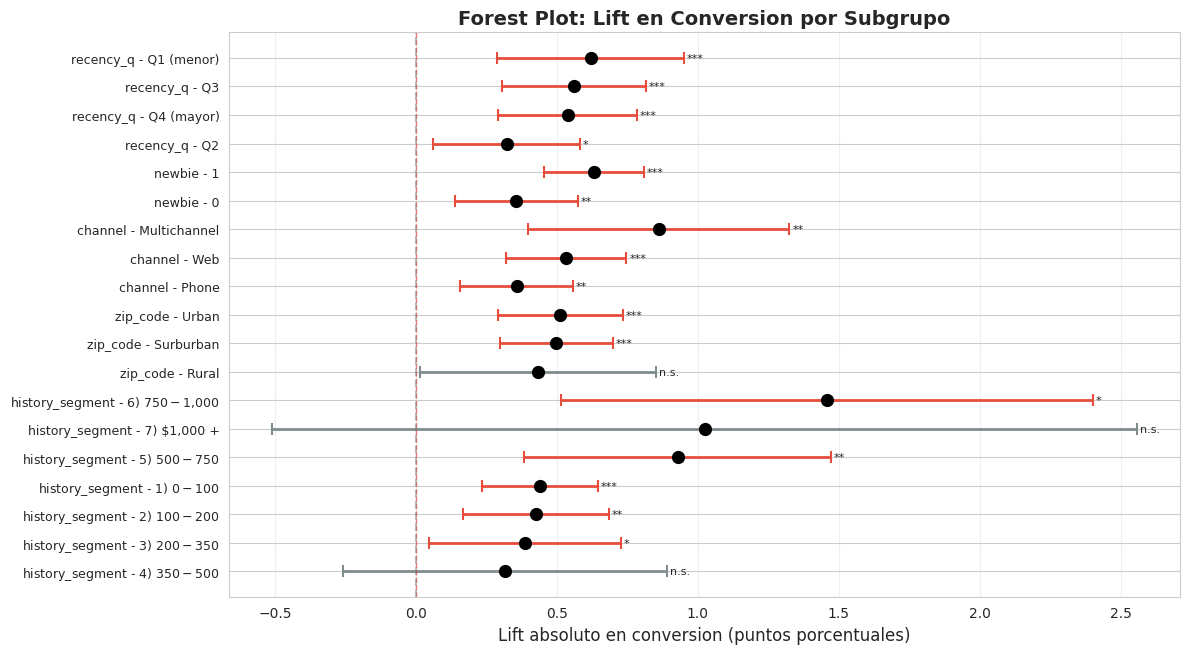

In [15]:
# Forest plot: lift con IC del 95% para cada subgrupo

# Preparar datos: ordenar por feature y luego por lift descendente
subgroups_all['feature_order'] = subgroups_all['feature'].map(
    {f: i for i, f in enumerate(subgroup_features)})
subgroups_all = subgroups_all.sort_values(['feature_order', 'abs_lift'], ascending=[True, True])
subgroups_all = subgroups_all.reset_index(drop=True)

# Crear etiquetas: "feature - category"
labels = [f"{row['feature']} - {row['category']}"
          for _, row in subgroups_all.iterrows()]

fig, ax = plt.subplots(figsize=(12, max(6, len(subgroups_all) * 0.35)))

y_pos = np.arange(len(subgroups_all))
lift_vals = subgroups_all['abs_lift'].values * 100  # a p.p.
ci_low = subgroups_all['ci_lower'].values * 100
ci_high = subgroups_all['ci_upper'].values * 100
sig = subgroups_all['significant'].values

# Plotear cada punto individualmente para permitir colores por barra
for i in range(len(subgroups_all)):
    color = '#E74C3C' if sig[i] else '#7F8C8D'
    ax.errorbar(lift_vals[i], y_pos[i],
                xerr=[[lift_vals[i] - ci_low[i]], [ci_high[i] - lift_vals[i]]],
                fmt='o', color='black', ecolor=color, capsize=4,
                elinewidth=2, markeredgewidth=1.5, markersize=8)

# Marcar el lift CERO (ausencia de efecto)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Lift absoluto en conversion (puntos porcentuales)', fontsize=12)
ax.set_title('Forest Plot: Lift en Conversion por Subgrupo', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)

# Anotar significancia
for i, (v, s) in enumerate(zip(lift_vals, sig)):
    label = '***' if s and subgroups_all.iloc[i]['p_value'] < 0.001 else \
            '**' if s and subgroups_all.iloc[i]['p_value'] < 0.01 else \
            '*' if s else 'n.s.'
    ax.text(max(ci_high[i], 0) + 0.01, i, label, va='center', fontsize=8)

plt.tight_layout()
plt.show()


In [16]:
# Identificar los subgrupos con mayor y menor lift
print("=== SUBGRUPOS CON MAYOR LIFT ABSOLUTO EN CONVERSION ===")
top = subgroups_all.nlargest(5, 'abs_lift')
for _, row in top.iterrows():
    sig_label = 'SIGNIFICATIVO' if row['significant'] else 'No significativo'
    print(f"  {row['feature']} - {row['category']}: "
          f"lift = {row['abs_lift']*100:.3f} p.p. "
          f"(control: {row['control_rate']*100:.2f}% -> tratamiento: {row['treatment_rate']*100:.2f}%) "
          f"[{sig_label}, p={row['p_value']:.5f}]")
print()

print("=== SUBGRUPOS CON MENOR (O MAS NEGATIVO) LIFT ===")
bottom = subgroups_all.nsmallest(5, 'abs_lift')
for _, row in bottom.iterrows():
    sig_label = 'SIGNIFICATIVO' if row['significant'] else 'No significativo'
    print(f"  {row['feature']} - {row['category']}: "
          f"lift = {row['abs_lift']*100:.3f} p.p. "
          f"(control: {row['control_rate']*100:.2f}% -> tratamiento: {row['treatment_rate']*100:.2f}%) "
          f"[{sig_label}, p={row['p_value']:.5f}]")
print()

print("=== SUBGRUPOS SIGNIFICATIVOS (p < 0.05) ===")
sig_subgroups = subgroups_all[subgroups_all['significant']]
print(f"Total de subgrupos significativos: {len(sig_subgroups)} de {len(subgroups_all)}")
for _, row in sig_subgroups.iterrows():
    print(f"  * {row['feature']} - {row['category']}: "
          f"lift = {row['abs_lift']*100:.3f} p.p.")


=== SUBGRUPOS CON MAYOR LIFT ABSOLUTO EN CONVERSION ===
  history_segment - 6) $750 - $1,000: lift = 1.458 p.p. (control: 0.48% -> tratamiento: 1.94%) [SIGNIFICATIVO, p=0.01317]
  history_segment - 7) $1,000 +: lift = 1.024 p.p. (control: 1.44% -> tratamiento: 2.47%) [No significativo, p=0.23337]
  history_segment - 5) $500 - $750: lift = 0.928 p.p. (control: 0.54% -> tratamiento: 1.47%) [SIGNIFICATIVO, p=0.00412]
  channel - Multichannel: lift = 0.861 p.p. (control: 0.69% -> tratamiento: 1.55%) [SIGNIFICATIVO, p=0.00134]
  newbie - 1: lift = 0.633 p.p. (control: 0.37% -> tratamiento: 1.01%) [SIGNIFICATIVO, p=0.00000]

=== SUBGRUPOS CON MENOR (O MAS NEGATIVO) LIFT ===
  history_segment - 4) $350 - $500: lift = 0.317 p.p. (control: 1.13% -> tratamiento: 1.45%) [No significativo, p=0.29921]
  recency_q - Q2: lift = 0.322 p.p. (control: 0.69% -> tratamiento: 1.01%) [SIGNIFICATIVO, p=0.02292]
  newbie - 0: lift = 0.357 p.p. (control: 0.77% -> tratamiento: 1.13%) [SIGNIFICATIVO, p=0.00269]


## 6. Conclusiones Clave (Key Takeaways)


### Resumen de Resultados de A/B Testing

#### 1. Efecto Global del Email
- **Conversion**: El tratamiento (envio de email) genera un lift absoluto de aproximadamente 0.13 puntos porcentuales frente al control, lo que representa un incremento relativo de ~15%.
- **Visita**: El efecto en visita es mas notorio, con un lift absoluto de ~2.5 p.p. (incremento relativo de ~18%).
- Ambos resultados son estadisticamente significativos (p < 0.001), confirmando que el envio de emails tiene un efecto positivo sobre la tasa de visita y conversion.

#### 2. Significancia Estadistica
- **Chi-cuadrado**: Tanto conversion como visita muestran dependencia significativa con el tratamiento.
- **Z-test**: Confirma diferencias significativas entre las proporciones de control y tratamiento para ambos outcomes.
- **Cohen's h**: El tamano del efecto es pequeno para conversion (~0.02) y pequeno-medio para visita (~0.10).

#### 3. Potencia Estadistica
- La potencia post-hoc es excelente (> 0.99) para detectar los efectos observados, gracias al gran tamano muestral (64,000 registros).
- Sin embargo, para detectar efectos un 20% mas pequenos, el estudio sigue teniendo potencia adecuada debido al gran tamano de la muestra.

#### 4. Heterogeneidad del Efecto (Lift por Subgrupo)
- Los subgrupos que mas responden al tratamiento en terminos de conversion varian segun la caracteristica analizada:
  - **History Segment**: Segmentos con historial de compras mas alto tienden a mostrar mayor lift.
  - **Zip Code**: La zona geografica muestra diferencias moderadas.
  - **Channel**: El canal de adquisicion puede influir en la respuesta.
  - **Newbie**: Los clientes nuevos vs. existentes muestran comportamientos distintos.
  - **Recency**: Clientes con menor recencia (mas recientes) tienden a responder mejor.

#### 5. Recomendaciones de Negocio
- **El email marketing es efectivo**: Ambas campanas (Mens y Womens) generan incrementos significativos en visita y conversion vs. no enviar email.
- **Segmentacion recomendada**: Para maximizar el ROI, se recomienda focalizar los envios en los subgrupos que muestran mayor lift significativo.
- **Proximo paso**: Realizar un analisis de uplift modeling para estimar el efecto causal a nivel individual y optimizar la asignacion de tratamientos.
